In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

# 多因子選股策略回測

## 策略說明
| 維度 | 權重 | 因子 |
|------|------|------|
| 成長 | 35% | 營收 YoY, EPS YoY（靜態）/ 3 個月動量（動態替代） |
| 財務 | 30% | 近一年 ROE 平均（靜態） |
| 創新 | 20% | 資本支出/營收（靜態） |
| 技術 | 15% | 30MA > 120MA（動態） |

**篩選條件**：台股大型股宇宙（約 50 檔）  
**換股頻率**：月底  
**持股檔數**：15  
**配置方式**：等權  
**Benchmark**：加權指數 ^TWII

In [10]:
# ── Cell 1：回測參數 ──

CONFIG = {
    "start": "2020-05-01",
    "end": "2026-05-01",
    "top_n": 15,
    "benchmark": "^TWII",
    "weight_method": "equal",
    "factor_weights": {
        "momentum_3m": 0.35,
        "roe_avg": 0.30,
        "capex_ratio": 0.20,
        "ma_bullish": 0.15,
    },
    "custom_tickers": None,
    "industry": '全部'  # <--- 填入'全部'、'半導體'、'建材營造' 等等，如果不篩選就維持 None
}

In [11]:
# ── Cell 2：抓取基本面因子（靜態分數） ──

from universe import get_universe
from factorize import fetch_factors_batch

# 1. 取得股票代碼 (加入產業篩選)
tickers = get_universe(
    tickers=CONFIG["custom_tickers"], 
    industry=CONFIG.get("industry")
)
print(f"宇宙：{len(tickers)} 檔")

# 2. 去抓取並計算財報分數
static_scores = fetch_factors_batch(tickers)
print("財報抓取完畢！")

宇宙：1792 檔
發現基本面快取 (大小: (1673, 7))。
需要抓取 119 檔標的的基本面資料...
  - 抓取進度: 1 / 119...
  - 抓取進度: 11 / 119...
  - 抓取進度: 21 / 119...
  - 抓取進度: 31 / 119...
  - 抓取進度: 41 / 119...
  - 抓取進度: 51 / 119...
  - 抓取進度: 61 / 119...
  - 抓取進度: 71 / 119...
  - 抓取進度: 81 / 119...
  - 抓取進度: 91 / 119...
  - 抓取進度: 101 / 119...
  - 抓取進度: 111 / 119...
財報抓取完畢！


下載 1792 檔股票 (2019-09-01 ~ 2026-05-01)...
發現本地價格快取 (大小: (4199, 1793))。
下載大盤 ^TWII...
發現本地價格快取 (大小: (4199, 1793))。
回測完成：1408 個交易日，71 次換股


,累積報酬,年化報酬,年化波動,Sharpe,最大回撤,最大回撤天數,月勝率,Kelly,報酬一階動差,報酬標準差,虧損一階動差,虧損標準差,交易日數
name,,,,,,,,,,,,,
策略,1765.82%,68.83%,29.90%,2.30,-28.77%,295,74.6%,0.1591,0.2258%,1.8838%,-1.4222%,1.3713%,1408
大盤,259.39%,25.73%,19.54%,1.32,-32.96%,511,64.8%,0.1126,0.0985%,1.2309%,-0.8712%,0.9432%,1408


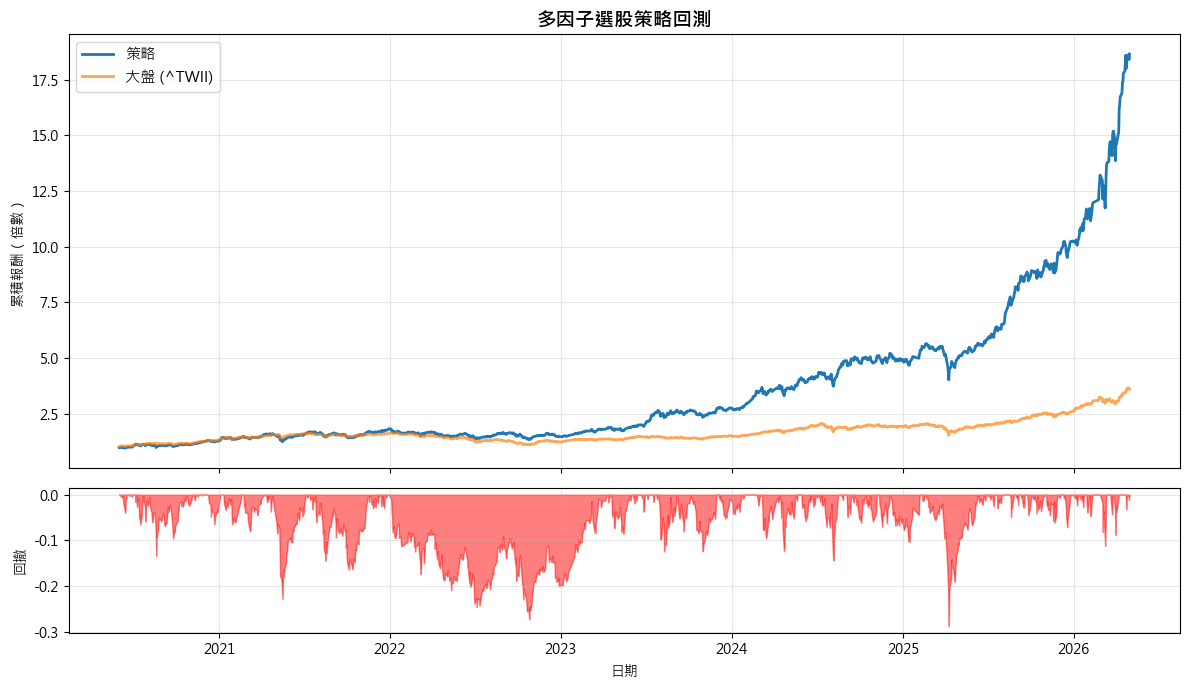

In [12]:
# ── Cell 3：執行回測 ──

from backtest import MultiFactorBacktester, equal_weight, score_weight

weight_fn = equal_weight if CONFIG["weight_method"] == "equal" else score_weight

bt = MultiFactorBacktester(
    tickers=tickers,
    start=CONFIG["start"],
    end=CONFIG["end"],
    top_n=CONFIG["top_n"],
    benchmark=CONFIG["benchmark"],
    factor_weights=CONFIG["factor_weights"],
    weight_fn=weight_fn,
    static_scores=static_scores,
    fee_rate=0.002
)

summary = bt.run()
display(summary)
fig = bt.plot()

,進場日期,出場日期,股票代號,產業類別,初始權重,區間報酬
0,2020-05-31,2020-06-30,2368.TW,電子零組件,6.67%,-11.11%
1,2020-05-31,2020-06-30,6532.TWO,半導體業,6.67%,-9.41%
2,2020-05-31,2020-06-30,6561.TWO,通信網路業,6.67%,-7.53%
3,2020-05-31,2020-06-30,3533.TW,電子零組件,6.67%,-7.46%
4,2020-05-31,2020-06-30,5439.TWO,電子零組件業,6.67%,-0.39%
...,...,...,...,...,...,...
1060,2026-03-31,2026-04-30,2449.TW,半導體,6.67%,15.90%
1061,2026-03-31,2026-04-30,3533.TW,電子零組件,6.67%,27.56%
1062,2026-03-31,2026-04-30,6574.TWO,生技醫療業,6.67%,-6.88%
1063,2026-03-31,2026-04-30,7751.TWO,半導體業,6.67%,75.36%



=== 月度換手率 ===
平均換手率：55.6%


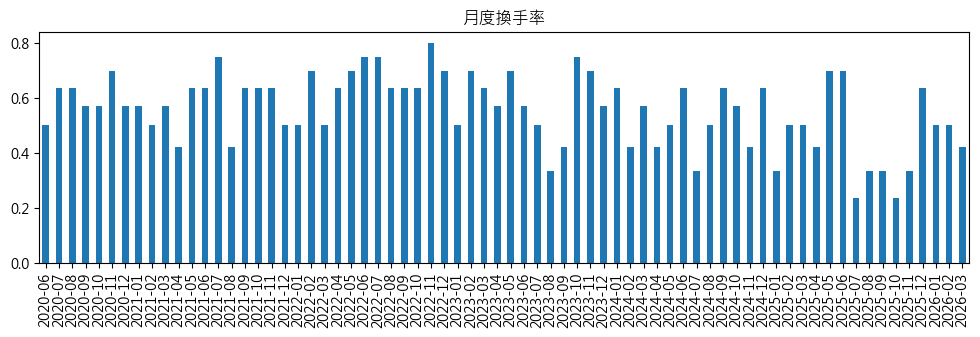

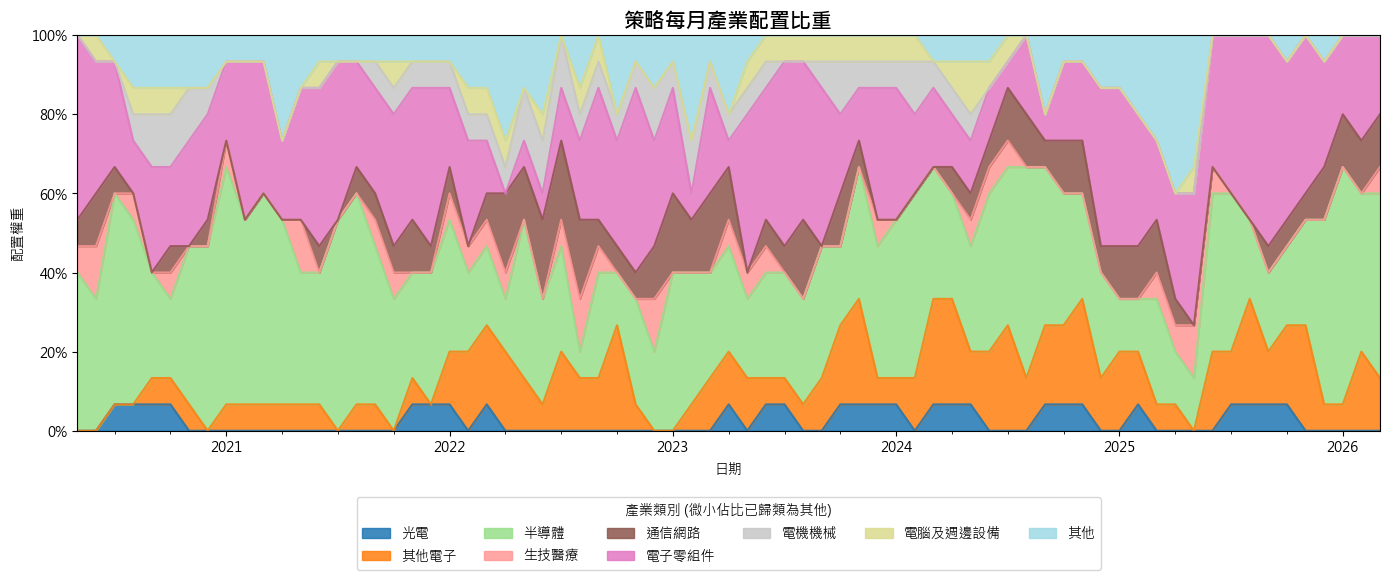

In [13]:
# ── Cell 5：information ──

trade_log = bt.get_trade_log()
display(trade_log)

print("\n=== 月度換手率 ===")
turnover = bt.turnover()
print(f"平均換手率：{turnover.mean():.1%}")
turnover.plot(kind="bar", figsize=(12, 3), title="月度換手率")

bt.plot_industry_weights()

下載 1792 檔股票 (2020-09-01 ~ 2026-05-01)...
發現本地價格快取 (大小: (4199, 1793))。
下載大盤 ^TWII...
發現本地價格快取 (大小: (4199, 1793))。
回測完成：1170 個交易日，59 次換股


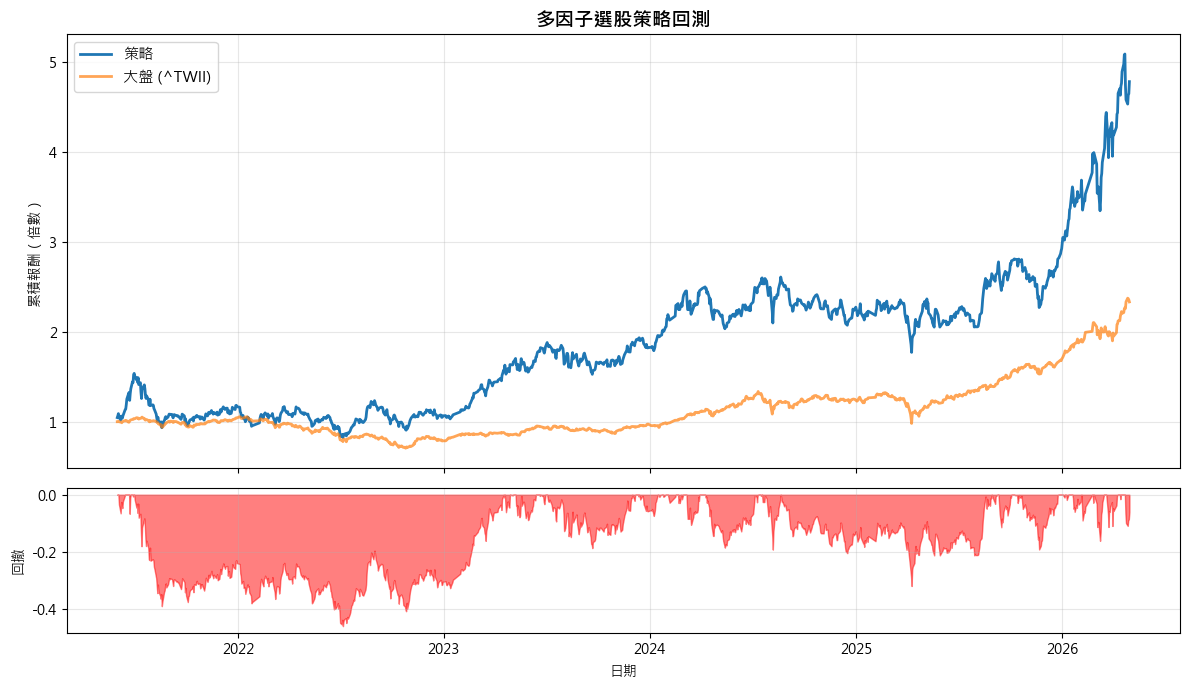

In [19]:
# ── Cell 6：實驗區（改參數重跑） ──

bt2 = MultiFactorBacktester(
    tickers=tickers,
    start="2021-05-01",
    end="2026-05-01",
    top_n=15,
    factor_weights={"momentum_3m": 0.7, "ma_bullish": 0.3},
    weight_fn=score_weight,
)
bt2.run()
fig2 = bt2.plot()